# Projeto 3: Otimizando Estratégias de E-Commerce com Análise de Dados

### Contextualização
O setor de e-commerce cresce rapidamente, mas enfrenta desafios na retenção de clientes, aumento do ticket médio e redução de cancelamentos. Empresas que vendem online precisam entender melhor o comportamento dos consumidores para criar estratégias de marketing mais eficientes e personalizadas.
Neste projeto, você atuará como um analista de dados contratado por uma loja de e-commerce para analisar transações passadas e identificar padrões que possam ajudar a empresa a melhorar as vendas, segmentar clientes e reduzir cancelamentos.

As transações estão registradas no arquivo data.csv 

### Problema de Negócio
##### Como o e-commerce pode identificar padrões de compra, segmentar clientes de forma eficiente e reduzir cancelamentos para aumentar a lucratividade?


### Objetivos  
**1.Compreensão do Negócio e do Problema**  
- Entender a dinâmica do e-commerce, os principais desafios e o que os dados podem revelar sobre os clientes.  
- Definir métricas de sucesso, como taxa de cancelamento, ticket médio e recorrência de compras.  

**2.Compreensão dos Dados**  
- Explorar a estrutura do dataset fornecido.  
- Verificar a qualidade dos dados: tratar valores ausentes, duplicados e inconsistentes.  
- Criar novas variáveis que possam ajudar na análise.  

**3.Análise Exploratória de Dados (EDA)**  
- Investigar padrões de compras ao longo do tempo.  
- Identificar os produtos mais vendidos e quais são frequentemente comprados juntos.  
- Avaliar o impacto dos preços e descontos nas vendas.  
- Analisar padrões de cancelamento de pedidos.  

**4.Segmentação de Clientes**  
- Criar grupos de clientes com base em comportamentos de compra.  
- Aplicar técnicas como RFM (Recência, Frequência e Valor Monetário) ou K-Means Clustering.  
- Analisar as características de cada segmento e sugerir estratégias de marketing personalizadas.  

**5.Geração de Insights e Recomendações**  
- Identificar padrões que podem ajudar na redução de cancelamentos.  
- Sugerir estratégias de fidelização para clientes de alto valor.  
- Apontar oportunidades de cross-sell e up-sell.  
- Fornecer insights para otimizar promoções e campanhas de marketing.  

## 1. Introdução e Contexto do Negócio  
O comércio eletrônico tem apresentado crescimento acelerado nos últimos anos, porém junto a esse crescimento surgem desafios importantes, como a retenção de clientes, o aumento do ticket médio e a redução de cancelamentos/devoluções de pedidos. No caso desta loja online (um e-commerce no segmento de presentes e utilidades domésticas), compreender o comportamento de compra dos consumidores por meio de dados históricos de transações é fundamental para otimizar estratégias comerciais e de marketing.  

Este relatório traz uma análise de dados completa, com foco em identificar padrões de compra, segmentar a base de clientes e extrair insights acionáveis para aumentar as vendas, melhorar a fidelização de clientes e reduzir cancelamentos.   

A seguir, o relatório está estruturado em seções que cobrem desde a compreensão e preparação dos dados até a análise exploratória, segmentação de clientes e recomendações estratégicas baseadas nos insights obtidos.

## 2. Descrição do Dataset e Preparação dos Dados  

O dataset analisado (arquivo data.csv) contém o registro de **541.909 transações** realizadas na loja online ao longo do período de **1º de Dezembro de 2010 a 9 de Dezembro de 2011**.   
Cada registro representa uma linha de item de um pedido (pedido identificado por ``InvoiceNo``).   

As colunas disponíveis são:

- **InvoiceNo**: Número da nota (fatura) do pedido. Pedidos cancelados são indicados por um prefixo 'C' neste número.  
- **StockCode**: Código do item (SKU).  
- **Description**: Descrição do produto.  
- **Quantity**: Quantidade do item comprada (valores negativos indicam devoluções/cancelamentos).  
- **InvoiceDate**: Data e hora da transação.  
- **UnitPrice**: Preço unitário do produto (em libras esterlinas £).  
- **CustomerID**: Identificador do cliente (cliente não identificado aparece como nulo).  
- **Country**: País do cliente.

### 2.1 - Importação das Bibliotecas e Carregamento do Dataset

In [1]:
# Fazendo a importação dos pacotes e funcionalidades que serão utilizadas ao longo do projeto

#Importando a dupla dinâmica
import pandas as pd
import numpy as np

#Carregando as bibliotecas gráficas...
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

#Carregando Ferramentas para estabelecimento de correlações
from itertools import combinations
from collections import Counter

#Carregando Datetime para trabalhar com segmentação de datas
import datetime as dt

#StandardScaler e KMeans para realizar a segmentação automática
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
# Suprimindo as mensagens de erro
import warnings
# Suprimir todos os warnings
warnings.filterwarnings('ignore')

In [3]:
# Carregando o Dataset
# Leitura dos dados (especificando encoding devido a caracteres especiais)
data = pd.read_csv('data.csv', encoding='latin-1')

In [4]:
# Ver as primeiras linhas do conjunto de dados
data.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
# Obter informações gerais do dataset (colunas, tipos, contagem de valores não-nulos)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
# Identificando Valores Ausentes
data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

### 2.2 - Engenharia de Dados - Limpeza e conversões

Vamos converter ``InvoiceDate`` para o tipo *datetime* para permitir agregações por período.  

In [7]:
# Conversão de InvoiceDate para datetime
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

Agora, vamos adicionar uma coluna ``TotalPrice`` para representar o valor monetário total de cada linha (``Quantity`` * ``UnitPrice``)

In [8]:
# Criando coluna de valor total por linha (TotalPrice = Quantity * UnitPrice)
data['TotalPrice'] = data['Quantity'] * data['UnitPrice']

In [9]:
# Vamos ver agora como ficou o dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
 8   TotalPrice   541909 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 37.2+ MB


In [10]:
# Ver as primeiras linhas do conjunto de dados
data.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [11]:
# Identificando Valores Ausentes
data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
TotalPrice          0
dtype: int64

**Verificação de Valores Ausentes**: Como pode ser observado a coluna ``CustomerID`` possui valores ausentes em ~135 mil registros (cerca de 25% dos dados). Essas transações sem identificação de cliente podem ser compras feitas por visitantes não cadastrados ou registros incompletos; elas serão mantidas para análise geral de vendas, porém não contribuirão na segmentação de clientes.   
Já a coluna ``Description`` apresentou 1.454 valores ausentes (0,27% dos registros). Analisando essas linhas, notou-se que geralmente eram ajustes de estoque ou itens com *UnitPrice = 0*, indicando brindes ou correções (“nan” na descrição e preço zero). Optamos por remover essas linhas de descrição ausente, pois não representam vendas reais de produtos.

In [12]:
# Removendo linhas com descrição ausente
data = data[ data['Description'].notna() ]

In [13]:
# Identificando Valores Ausentes
data.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133626
Country             0
TotalPrice          0
dtype: int64

**Verificando Registros Duplicados**

In [14]:
# Verificar duplicatas completas (todas as colunas iguais)
print(f"Linhas totalmente duplicadas: {data.duplicated().sum()}")

# Verificar se há produtos repetidos no mesmo pedido (InvoiceNo + StockCode)
duplicados_pedido = data[data.duplicated(['InvoiceNo', 'StockCode'], keep=False)]
print(f"Produtos repetidos no mesmo pedido: {len(duplicados_pedido)}")

Linhas totalmente duplicadas: 5268
Produtos repetidos no mesmo pedido: 20378


**Remoção de Duplicatas**: Foram detectadas e removidas **5.268 linhas duplicadas** (registros idênticos repetidos), evitando distorção das contagens de vendas.

In [15]:
# Removendo linhas duplicadas exatas
data = data.drop_duplicates()

In [16]:
# Vamos ver agora como ficou o dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 535187 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    535187 non-null  object        
 1   StockCode    535187 non-null  object        
 2   Description  535187 non-null  object        
 3   Quantity     535187 non-null  int64         
 4   InvoiceDate  535187 non-null  datetime64[ns]
 5   UnitPrice    535187 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      535187 non-null  object        
 8   TotalPrice   535187 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 40.8+ MB


**Cancelamentos e Devoluções**: Em pedidos cancelados, é comum aparecer no dataset tanto o registro original da venda quanto uma linha com quantidade negativa correspondendo à devolução (às vezes em uma fatura separada indicada pelo prefixo 'C').  
No total, identificamos **10.624 registros** com quantidade negativa, indicando itens devolvidos.  

Para a análise de vendas (vendas efetivas), consideramos apenas transações com **Quantity > 0**.   

Já para analisar cancelamentos, utilizamos os registros de quantidade negativa separadamente.   

Notou-se também que **9.288 faturas** possuem prefixo 'C' (notas de crédito), as quais correspondem a devoluções de pedidos. Ou seja, uma parcela significativa dos pedidos gerou devoluções (parciais ou totais). Este fator será explorado adiante, dada sua importância para o negócio.

In [17]:
# Separando dataset de vendas (exclui devoluções) e dataset de cancelamentos
sales_data = data[data['Quantity'] > 0].copy()      # apenas itens vendidos
returns_data = data[data['Quantity'] < 0].copy()    # itens devolvidos

In [18]:
# Verificando as quantidades de cada novo dataset
print(sales_data.shape, returns_data.shape)

(525462, 9) (9725, 9)


In [19]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 525462 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    525462 non-null  object        
 1   StockCode    525462 non-null  object        
 2   Description  525462 non-null  object        
 3   Quantity     525462 non-null  int64         
 4   InvoiceDate  525462 non-null  datetime64[ns]
 5   UnitPrice    525462 non-null  float64       
 6   CustomerID   392732 non-null  float64       
 7   Country      525462 non-null  object        
 8   TotalPrice   525462 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 40.1+ MB


In [20]:
returns_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9725 entries, 141 to 541717
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    9725 non-null   object        
 1   StockCode    9725 non-null   object        
 2   Description  9725 non-null   object        
 3   Quantity     9725 non-null   int64         
 4   InvoiceDate  9725 non-null   datetime64[ns]
 5   UnitPrice    9725 non-null   float64       
 6   CustomerID   8872 non-null   float64       
 7   Country      9725 non-null   object        
 8   TotalPrice   9725 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 759.8+ KB


In [21]:
returns_data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,-27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,-4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96


**Criação de Colunas Derivadas** para facilitar o processo de Análise

Vamos criar campos derivados para auxiliar na análise, como por exemplo:  
- Coluna de mês/ano da compra (Month), extraída de InvoiceDate para análise temporal mensal.  
- Coluna booleana indicando se o registro é uma devolução (IsReturn), para facilitar filtros.  
- (Poderíamos criar também um identificador de pedido completo, porém aqui InvoiceNo já exerce esse papel, representando a fatura/pedido.)

In [22]:
# Criando coluna de período mensal (ano-mês)
sales_data['Month'] = sales_data['InvoiceDate'].dt.to_period('M')

In [23]:
# Marcando devoluções
data['IsReturn'] = data['Quantity'] < 0

#### Como ficou o dataset após o processo de Engenharia de Dados e breve limpeza

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 535187 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    535187 non-null  object        
 1   StockCode    535187 non-null  object        
 2   Description  535187 non-null  object        
 3   Quantity     535187 non-null  int64         
 4   InvoiceDate  535187 non-null  datetime64[ns]
 5   UnitPrice    535187 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      535187 non-null  object        
 8   TotalPrice   535187 non-null  float64       
 9   IsReturn     535187 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 41.3+ MB


In [25]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 525462 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    525462 non-null  object        
 1   StockCode    525462 non-null  object        
 2   Description  525462 non-null  object        
 3   Quantity     525462 non-null  int64         
 4   InvoiceDate  525462 non-null  datetime64[ns]
 5   UnitPrice    525462 non-null  float64       
 6   CustomerID   392732 non-null  float64       
 7   Country      525462 non-null  object        
 8   TotalPrice   525462 non-null  float64       
 9   Month        525462 non-null  period[M]     
dtypes: datetime64[ns](1), float64(3), int64(1), object(4), period[M](1)
memory usage: 44.1+ MB


In [26]:
returns_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9725 entries, 141 to 541717
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    9725 non-null   object        
 1   StockCode    9725 non-null   object        
 2   Description  9725 non-null   object        
 3   Quantity     9725 non-null   int64         
 4   InvoiceDate  9725 non-null   datetime64[ns]
 5   UnitPrice    9725 non-null   float64       
 6   CustomerID   8872 non-null   float64       
 7   Country      9725 non-null   object        
 8   TotalPrice   9725 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 759.8+ KB


In [27]:
# Total de Invoces únicas das vendas...
print(sales_data['InvoiceNo'].nunique(), "Invoces únicas de um total de", len(sales_data), "entradas.")

20136 Invoces únicas de um total de 525462 entradas.


In [28]:
# Total de Clientes únicos das vendas...
print(sales_data['CustomerID'].nunique(), "Custumers únicos de um total de", len(sales_data), "entradas.")

4339 Custumers únicos de um total de 525462 entradas.


In [29]:
# Contagem de Pedidos por País, com percentual correspondente...
# 1. Calcular total de itens por país
itens_por_pais = sales_data['Country'].value_counts().reset_index()
itens_por_pais.columns = ['Country', 'Total_Itens']

# 2. Calcular percentual e formatar como string com '%'
itens_por_pais['Percentual'] = (itens_por_pais['Total_Itens'] / itens_por_pais['Total_Itens'].sum() * 100).round(1).astype(str) + '%'

# 3. Ordenar do maior para o menor
itens_por_pais = itens_por_pais.sort_values('Total_Itens', ascending=False)

# Imprimir o resultado
print(itens_por_pais)

                 Country  Total_Itens Percentual
0         United Kingdom       480551      91.5%
1                Germany         9027       1.7%
2                 France         8393       1.6%
3                   EIRE         7883       1.5%
4                  Spain         2480       0.5%
5            Netherlands         2363       0.4%
6                Belgium         2031       0.4%
7            Switzerland         1959       0.4%
8               Portugal         1492       0.3%
9              Australia         1184       0.2%
10                Norway         1072       0.2%
11                 Italy          758       0.1%
12       Channel Islands          747       0.1%
13               Finland          685       0.1%
14                Cyprus          603       0.1%
15                Sweden          450       0.1%
16           Unspecified          442       0.1%
17               Austria          398       0.1%
18               Denmark          380       0.1%
19                Po

Após a limpeza, o dataset final de vendas contém **525.462 registros de itens vendidos** (excluindo duplicatas e devoluções) correspondentes a **20.136 pedidos únicos** e **4.339 clientes distintos**.   
A maior parte das vendas ocorreu para clientes do Reino Unido (mais de **91% dos pedidos**), seguido por alguns países da Europa (como Alemanha e França), refletindo que a loja tem foco principal no mercado britânico, mas atende internacionalmente em menor escala.

## 3. Análise Exploratória dos Dados (EDA) 

Com os dados preparados, vamos realizar a Análise Exploratória para identificar padrões nas vendas, produtos de melhor desempenho, comportamento de preços e cancelamentos, bem como relações entre itens comprados em conjunto.  

### 3.1. Padrões de Compras ao Longo do Tempo

Começamos investigando a evolução das vendas ao longo do período.   
Como o dataset cobre aproximadamente um ano de transações... Assim, vamos agregar as vendas por mês para identificar tendências sazonais ou crescimento/declínio de vendas mensais.   
Vamos calcular tanto o volume de vendas (quantidade de itens vendidos) quanto a receita (soma de ``TotalPrice``) por mês.  

In [30]:
# Agregando vendas mensais (receita total por mês)
monthly_revenue = sales_data.groupby('Month')['TotalPrice'].sum()
print(monthly_revenue)


Month
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     735717.260
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637790.330
Freq: M, Name: TotalPrice, dtype: float64


A saída acima fornece a receita total de cada mês entre 2010-12 e 2011-12.   

Observando os valores (e plotando em gráfico - célula a seguir), nota-se claramente um padrão sazonal: houve um pico acentuado de vendas no final de 2011, precedido por um crescimento consistente a partir do meio do ano.   

Em especial, Novembro de 2011 foi o mês com maior faturamento (aproximadamente £1,5 milhão), indicando o efeito das compras de fim de ano (Natal).   

Já os primeiros meses de 2011 (especialmente janeiro e fevereiro) apresentaram faturamento menor, possivelmente refletindo a ressaca pós-festas e menor atividade promocional.

Graficamente temos o seguinte:

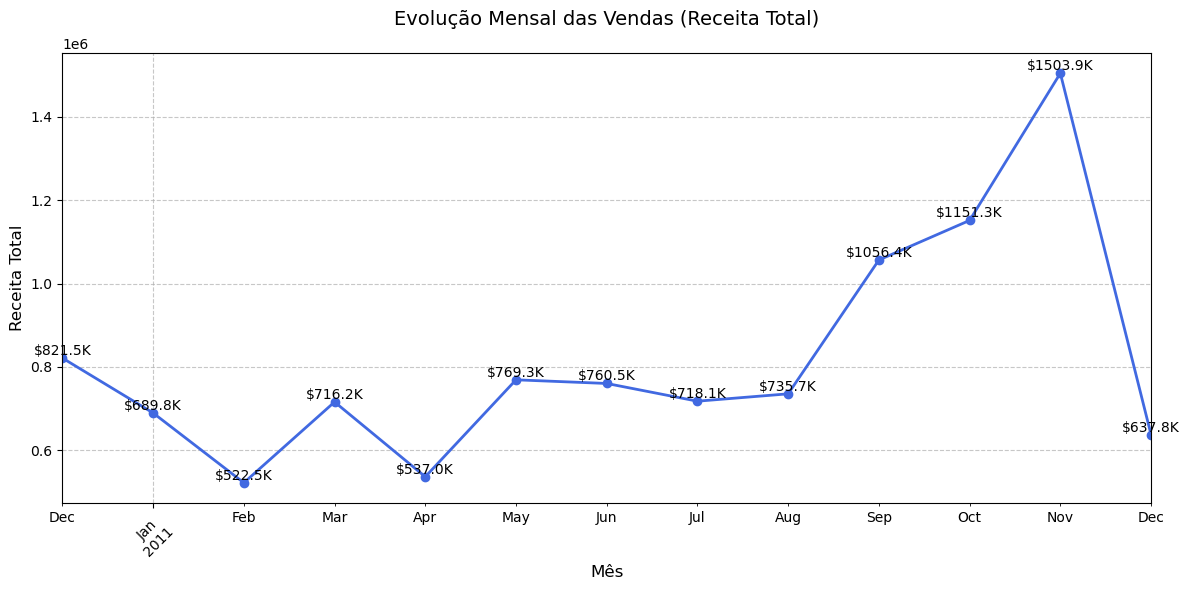

In [31]:
# Criar o gráfico de linha
plt.figure(figsize=(12, 6))  # Define o tamanho do gráfico
monthly_revenue.plot(kind='line', 
                     marker='o',  # Adiciona marcadores nos pontos
                     linewidth=2, 
                     color='royalblue')

# Personalizar o gráfico
plt.title('Evolução Mensal das Vendas (Receita Total)', fontsize=14, pad=20)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Receita Total', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)  # Adiciona grid
plt.xticks(rotation=45)  # Rotaciona os rótulos dos meses para melhor legibilidade

# Adicionar rótulos de valor em cada ponto
for x, y in zip(monthly_revenue.index, monthly_revenue.values):
    plt.text(x, y, f'${y/1000:.1f}K', ha='center', va='bottom')

plt.tight_layout()  # Ajusta o layout para evitar cortes
plt.show()

Além da tendência anual, pode-se observar padrões intra-anuais: por exemplo, ao detalhar por mês do ano, fica evidente que Dezembro de 2010 (dados parciais) e Dezembro de 2011 (dados até dia 9 apenas) não atingem o pico de novembro.   
Possivelmente, se os dados de Dezembro/2011 estivessem completos, observaríamos outro pico próximo ao de novembro.   
Essa informação sugere forte sazonalidade de fim de ano, importante para planejamento de estoque e campanhas promocionais.  

**Análise de Pedidos por dia da Semana e Hora**

In [32]:
# Para tanto, temos que fazer uma pequena preparação dos dados...

# Extrair dia da semana e hora de InvoiceDate
data['DiaSemana'] = data['InvoiceDate'].dt.day_name()
data['Hora'] = data['InvoiceDate'].dt.hour

# Ordem correta dos dias
dias_ordenados = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
data['DiaSemana'] = pd.Categorical(data['DiaSemana'], categories=dias_ordenados, ordered=True)

# Contar pedidos únicos por dia/hora
pedidos_dia_hora = data.groupby(['DiaSemana', 'Hora'])['InvoiceNo'].nunique().reset_index()

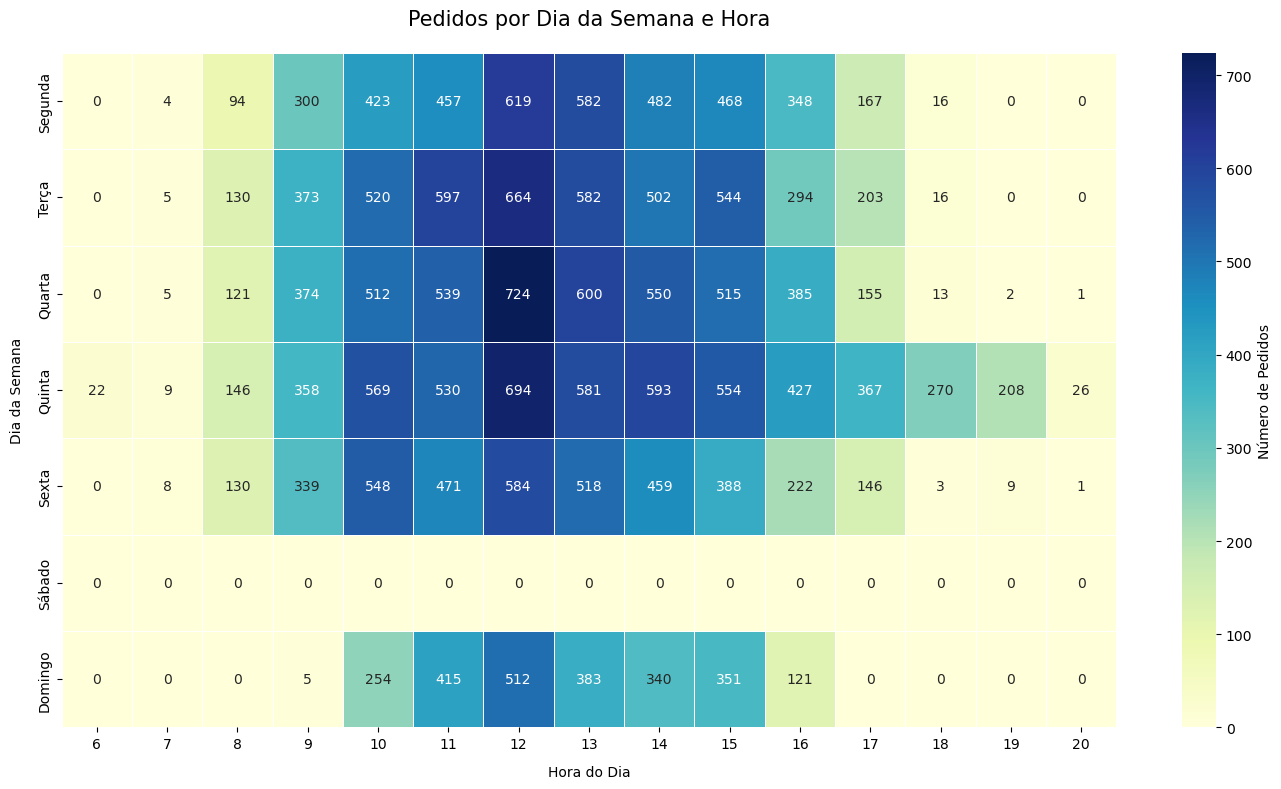

In [33]:
# FAZENDO O PLOT COM O MAPA DE CALOR

plt.figure(figsize=(14, 8))

# Versão CORRETA usando pivot_table
heatmap_data = pedidos_dia_hora.pivot_table(
    index="DiaSemana", 
    columns="Hora", 
    values="InvoiceNo",
    fill_value=0  # Preenche horas sem pedidos com 0
)

# Converter para formato português se necessário
dias_portugues = {
    'Monday': 'Segunda',
    'Tuesday': 'Terça',
    'Wednesday': 'Quarta',
    'Thursday': 'Quinta',
    'Friday': 'Sexta',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo'
}
heatmap_data.index = heatmap_data.index.map(dias_portugues)

sns.heatmap(heatmap_data, cmap="YlGnBu", annot=True, fmt=".0f", 
            linewidths=.5, cbar_kws={'label': 'Número de Pedidos'})

plt.title('Pedidos por Dia da Semana e Hora', pad=20, fontsize=15)
plt.xlabel('Hora do Dia', labelpad=10)
plt.ylabel('Dia da Semana', labelpad=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

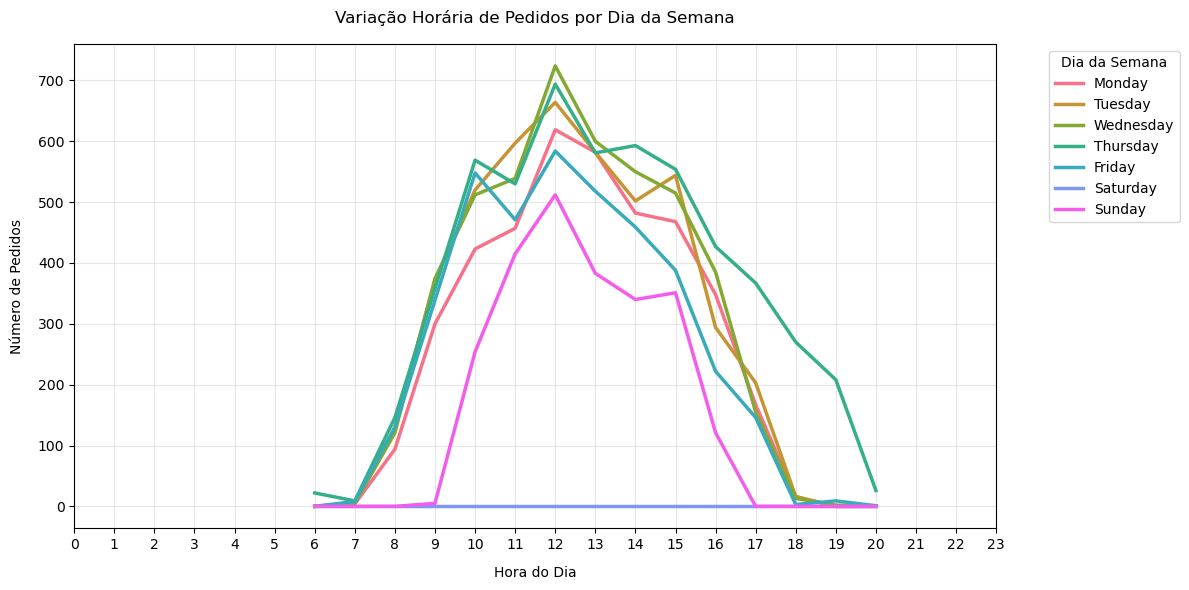

In [34]:
# FAZER A EXIBIÇÃO COM GRAFICO DE LINHA POR DIA

plt.figure(figsize=(12, 6))
sns.lineplot(data=pedidos_dia_hora, x='Hora', y='InvoiceNo', hue='DiaSemana',
             palette="husl", linewidth=2.5)

plt.title('Variação Horária de Pedidos por Dia da Semana', pad=15)
plt.xlabel('Hora do Dia', labelpad=10)
plt.ylabel('Número de Pedidos', labelpad=10)
plt.grid(True, alpha=0.3)
plt.legend(title='Dia da Semana', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

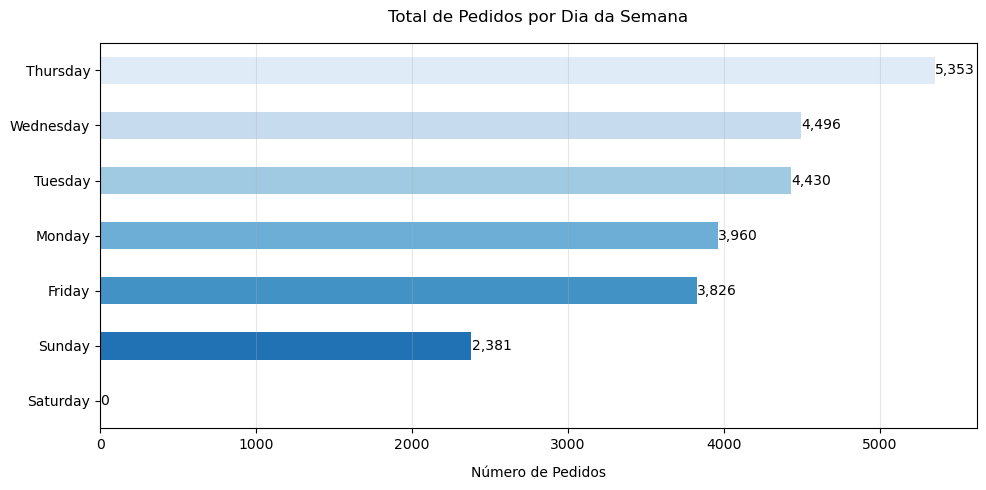

In [35]:
# FAZER A EXIBIÇÃO COM GRÁFICO DE BARRAS AGREGADO

# Pedidos por dia
pedidos_dia = data.groupby('DiaSemana')['InvoiceNo'].nunique().sort_values()

plt.figure(figsize=(10, 5))
pedidos_dia.plot(kind='barh', color=sns.color_palette("Blues_r", 7))

plt.title('Total de Pedidos por Dia da Semana', pad=15)
plt.xlabel('Número de Pedidos', labelpad=10)
plt.ylabel('')
plt.grid(axis='x', alpha=0.3)

# Adicionar valores nas barras
for i, v in enumerate(pedidos_dia):
    plt.text(v + 3, i, f"{v:,}", color='black', va='center')

plt.tight_layout()
plt.show()

### 3.2 Produtos mais vendidos e Preferências dos Clientes
Identificar quais produtos são mais vendidos e quais combinações de produtos são frequentemente compradas juntas, para entender o mix de produtos e oportunidades de cross-sell.

Calculando o total de unidades vendidas por produto

In [36]:
# Top 10 produtos por quantidade vendida
top_products_qty = sales_data.groupby('Description')['Quantity'].sum().sort_values(ascending=False)
print(top_products_qty.head(10))

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48375
WHITE HANGING HEART T-LIGHT HOLDER    37876
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64


Calculando a receita total por produto

In [37]:
# Top 10 produtos por receita gerada
top_products_rev = sales_data.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False)
print(top_products_rev.head(10))

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: TotalPrice, dtype: float64


Verificando o total de unidades devolvidas por produto

In [38]:
# Top 10 produtos DEVOLVIDOS por quantidade vendida
top_products_dev_qty = returns_data.groupby('Description')['Quantity'].sum().sort_values(ascending=True)
print(top_products_dev_qty.head(10))


Description
PAPER CRAFT , LITTLE BIRDIE           -80995
MEDIUM CERAMIC TOP STORAGE JAR        -74494
printing smudges/thrown away          -19200
Unsaleable, destroyed.                -15644
check                                 -13247
?                                      -9496
ROTATING SILVER ANGELS T-LIGHT HLDR    -9376
Printing smudges/thrown away           -9058
Damaged                                -7540
throw away                             -5368
Name: Quantity, dtype: int64


Vamos ver o comportamento das compras realizadas em conjunto... itens diferentes em uma mesma Invoice.

In [39]:
pairs_counter = Counter()
# Agrupa descrições por pedido e conta combinações de 2 produtos
for invoice, items in sales_data.groupby('InvoiceNo')['Description']:
    unique_items = items.unique()
    for combo in combinations(unique_items, 2):
        pairs_counter[ tuple(sorted(combo)) ] += 1

# Top 10 pares mais frequentes
for combo, count in pairs_counter.most_common(10):
    print(combo, "->", count, "pedidos em comum")

('JUMBO BAG PINK POLKADOT', 'JUMBO BAG RED RETROSPOT') -> 825 pedidos em comum
('GREEN REGENCY TEACUP AND SAUCER', 'ROSES REGENCY TEACUP AND SAUCER ') -> 768 pedidos em comum
('JUMBO BAG RED RETROSPOT', 'JUMBO STORAGE BAG SUKI') -> 724 pedidos em comum
('JUMBO BAG RED RETROSPOT', 'JUMBO SHOPPER VINTAGE RED PAISLEY') -> 680 pedidos em comum
('LUNCH BAG  BLACK SKULL.', 'LUNCH BAG RED RETROSPOT') -> 641 pedidos em comum
('ALARM CLOCK BAKELIKE GREEN', 'ALARM CLOCK BAKELIKE RED ') -> 640 pedidos em comum
('GREEN REGENCY TEACUP AND SAUCER', 'PINK REGENCY TEACUP AND SAUCER') -> 633 pedidos em comum
('LUNCH BAG PINK POLKADOT', 'LUNCH BAG RED RETROSPOT') -> 606 pedidos em comum
('PINK REGENCY TEACUP AND SAUCER', 'ROSES REGENCY TEACUP AND SAUCER ') -> 599 pedidos em comum
('JUMBO  BAG BAROQUE BLACK WHITE', 'JUMBO BAG RED RETROSPOT') -> 585 pedidos em comum


### 3.3 Relação entre Preço, Quantidade e Cancelamentos
Vamos analisar agora a relação entre preço unitário e quantidade comprada, bem como como esses fatores se relacionam com os cancelamentos.   
Intuitivamente, espera-se que itens mais baratos sejam comprados em quantidades maiores (por serem acessíveis ou consumíveis), enquanto itens caros tendem a ser adquiridos em poucas unidades por pedido.  
Para verificar isso, vamos calcular a correlação entre preço e quantidade e também vamos visualizar as distribuições:

In [40]:
# 1. Filtrar dados inválidos
valid_data = sales_data[
    (sales_data['UnitPrice'] > 0) & 
    (sales_data['Quantity'] > 0)
].copy()

# 2. Calcular correlações
corr_pearson = valid_data['UnitPrice'].corr(valid_data['Quantity'])
corr_spearman = valid_data['UnitPrice'].corr(valid_data['Quantity'], method='spearman')

# 3. Calcular correlação log (apenas para dados válidos)
valid_data['log_UnitPrice'] = np.log(valid_data['UnitPrice'])
valid_data['log_Quantity'] = np.log(valid_data['Quantity'])
corr_log = valid_data['log_UnitPrice'].corr(valid_data['log_Quantity'])

print(f"""
Correlação Pearson (linear): {corr_pearson:.4f}
Correlação Spearman (monotônica): {corr_spearman:.4f}
Correlação log-transformada: {corr_log:.4f}
""")


Correlação Pearson (linear): -0.0038
Correlação Spearman (monotônica): -0.4087
Correlação log-transformada: -0.4231



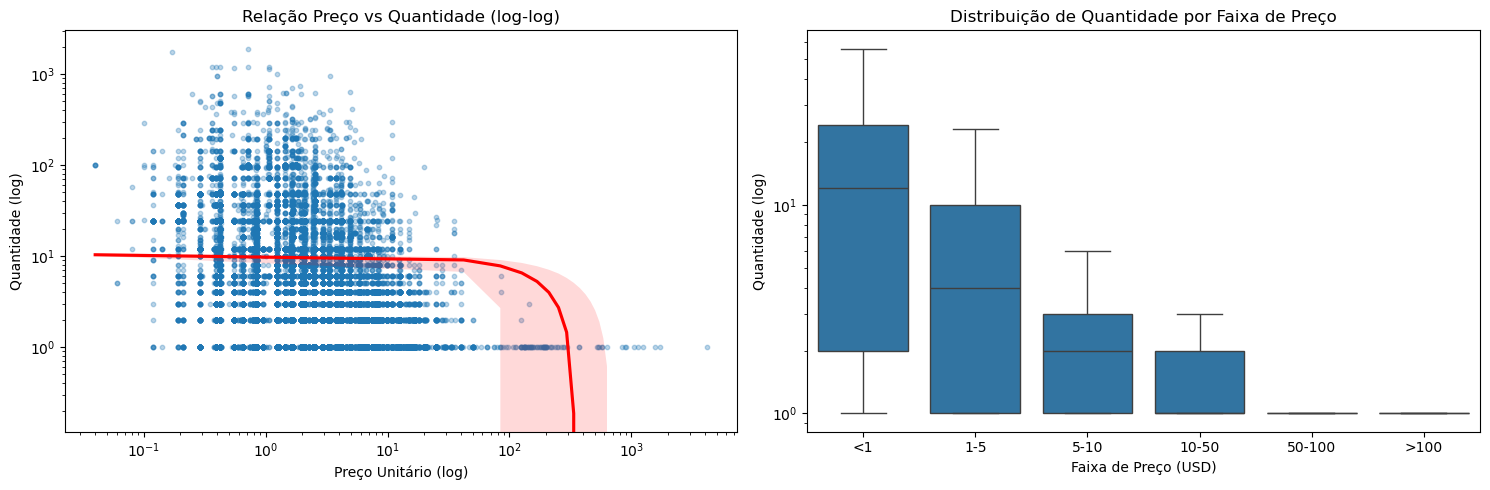

In [41]:
# 4. Visualização avançada
plt.figure(figsize=(15, 5))

# Gráfico 1: Dispersão com regressão
plt.subplot(1, 2, 1)
sns.regplot(data=valid_data.sample(frac=0.1),  # Amostra para melhor visualização
            x='UnitPrice', 
            y='Quantity',
            scatter_kws={'alpha': 0.3, 's': 10},
            line_kws={'color': 'red'})
plt.xscale('log')
plt.yscale('log')
plt.title('Relação Preço vs Quantidade (log-log)')
plt.xlabel('Preço Unitário (log)')
plt.ylabel('Quantidade (log)')

# Gráfico 2: Boxplot por faixa de preço
plt.subplot(1, 2, 2)
valid_data['price_bin'] = pd.cut(valid_data['UnitPrice'], 
                                bins=[0, 1, 5, 10, 50, 100, np.inf],
                                labels=['<1', '1-5', '5-10', '10-50', '50-100', '>100'])
sns.boxplot(data=valid_data, x='price_bin', y='Quantity', showfliers=False)
plt.yscale('log')
plt.title('Distribuição de Quantidade por Faixa de Preço')
plt.xlabel('Faixa de Preço (USD)')
plt.ylabel('Quantidade (log)')

plt.tight_layout()
plt.show()

Analisando os **cancelamentos / devoluções** e seus padrões...

In [42]:
## Preparação dos dados para essa análise

# Criar coluna de identificação de devoluções
sales_data['is_return'] = sales_data['InvoiceNo'].isin(returns_data['InvoiceNo'])

# Separar dados
devolvidos = sales_data[sales_data['is_return']]
mantidos = sales_data[~sales_data['is_return']]

In [43]:
## Verificação inicial
print(f"Total de registros de devolução: {len(returns_data)}")
print(f"Registros de vendas marcados como devolução: {sales_data['is_return'].sum()}")

## Análise estatística básica
if sales_data['is_return'].sum() > 0:
    # Análise estatística básica
    print("\n=== Estatísticas Descritivas ===")
    print("\nTodos os produtos:")
    print(sales_data['UnitPrice'].describe().round(2))
    
    print("\nProdutos devolvidos:")
    print(devolvidos['UnitPrice'].describe().round(2))
    
    print("\nProdutos mantidos:")
    print(mantidos['UnitPrice'].describe().round(2))
else:
    print("\nAVISO: Nenhum registro de devolução encontrado. Verifique:")
    print("1. A coluna de InvoiceNo nos DataFrames sales_data e returns_data")
    print("2. Se os dados de returns_data foram carregados corretamente")
    
    # Sugestão para diagnóstico:
    print("\nValores únicos em sales_data['InvoiceNo']:", sales_data['InvoiceNo'].nunique())
    print("Valores únicos em returns_data['InvoiceNo']:", returns_data['InvoiceNo'].nunique())
    print("Interseção entre os conjuntos:", 
          len(set(sales_data['InvoiceNo']).intersection(set(returns_data['InvoiceNo']))))

Total de registros de devolução: 9725
Registros de vendas marcados como devolução: 0

AVISO: Nenhum registro de devolução encontrado. Verifique:
1. A coluna de InvoiceNo nos DataFrames sales_data e returns_data
2. Se os dados de returns_data foram carregados corretamente

Valores únicos em sales_data['InvoiceNo']: 20136
Valores únicos em returns_data['InvoiceNo']: 4310
Interseção entre os conjuntos: 0


In [44]:
print("\nRegistros com preço negativo:")
print(sales_data[sales_data['UnitPrice'] < 0][['InvoiceNo', 'StockCode', 'Description', 'UnitPrice']])


Registros com preço negativo:
       InvoiceNo StockCode      Description  UnitPrice
299983   A563186         B  Adjust bad debt  -11062.06
299984   A563187         B  Adjust bad debt  -11062.06


In [45]:
## Comparação de valores

comparacao = pd.DataFrame({
    'Todos': sales_data['UnitPrice'].describe(),
    'Devolvidos': devolvidos['UnitPrice'].describe(),
    'Mantidos': mantidos['UnitPrice'].describe()
})

# Calcular diferenças percentuais
comparacao['Dif_Devolvidos_vs_Mantidos'] = ((comparacao['Devolvidos'] - comparacao['Mantidos']) / comparacao['Mantidos']) * 100
print("\nComparação detalhada:")
print(comparacao[['Devolvidos', 'Mantidos', 'Dif_Devolvidos_vs_Mantidos']].round(2))


Comparação detalhada:
       Devolvidos   Mantidos  Dif_Devolvidos_vs_Mantidos
count         0.0  525462.00                      -100.0
mean          NaN       3.88                         NaN
std           NaN      42.04                         NaN
min           NaN  -11062.06                         NaN
25%           NaN       1.25                         NaN
50%           NaN       2.08                         NaN
75%           NaN       4.13                         NaN
max           NaN   13541.33                         NaN


In [46]:
## 4. Análise de outliers
# Definir outliers como preços acima do percentil 95
threshold = sales_data['UnitPrice'].quantile(0.95)
outliers_devolvidos = devolvidos[devolvidos['UnitPrice'] > threshold]

print(f"\nNúmero de outliers devolvidos (preço > {threshold:.2f}): {len(outliers_devolvidos)}")
print("Top 5 produtos mais caros devolvidos:")
print(outliers_devolvidos.nlargest(5, 'UnitPrice')[['StockCode', 'Description', 'UnitPrice']])


Número de outliers devolvidos (preço > 9.95): 0
Top 5 produtos mais caros devolvidos:
Empty DataFrame
Columns: [StockCode, Description, UnitPrice]
Index: []


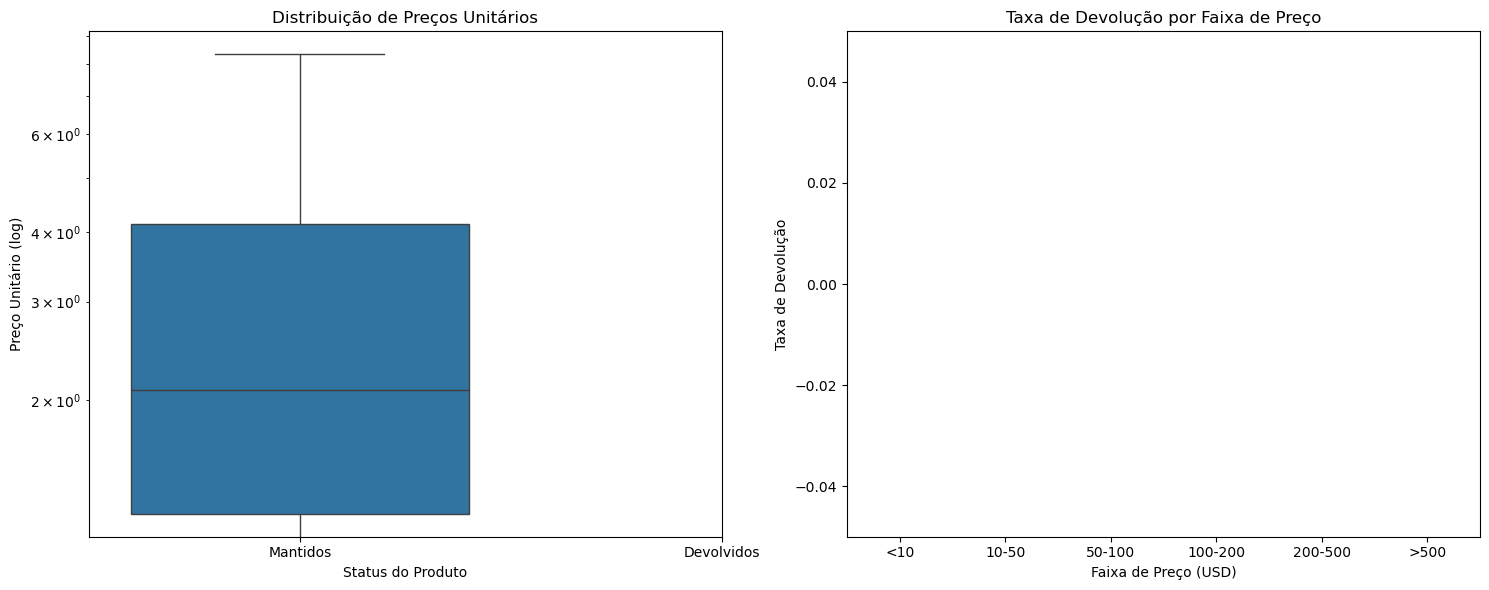

In [47]:
## 5. Visualizações
plt.figure(figsize=(15, 6))

# Gráfico 1: Distribuição de preços
plt.subplot(1, 2, 1)
sns.boxplot(data=sales_data, x='is_return', y='UnitPrice', showfliers=False)
plt.yscale('log')
plt.title('Distribuição de Preços Unitários')
plt.xlabel('Status do Produto')
plt.ylabel('Preço Unitário (log)')
plt.xticks([0, 1], ['Mantidos', 'Devolvidos'])

# Gráfico 2: Proporção de devoluções por faixa de preço
plt.subplot(1, 2, 2)
sales_data['price_bin'] = pd.cut(sales_data['UnitPrice'], 
                                bins=[0, 10, 50, 100, 200, 500, np.inf],
                                labels=['<10', '10-50', '50-100', '100-200', '200-500', '>500'])

return_rates = sales_data.groupby('price_bin')['is_return'].mean().reset_index()
sns.barplot(data=return_rates, x='price_bin', y='is_return')
plt.title('Taxa de Devolução por Faixa de Preço')
plt.xlabel('Faixa de Preço (USD)')
plt.ylabel('Taxa de Devolução')
plt.ylim(0, return_rates['is_return'].max() * 1.1)

plt.tight_layout()
plt.show()


In [48]:
## 6. Análise adicional - Produtos mais devolvidos
print("\nTop 10 produtos mais devolvidos:")
top_devolvidos = devolvidos['StockCode'].value_counts().head(10)
print(top_devolvidos)

# Verificar descrição dos produtos mais devolvidos
top_devolvidos_desc = sales_data[sales_data['StockCode'].isin(top_devolvidos.index)][['StockCode', 'Description']].drop_duplicates()
print("\nDescrição dos produtos mais devolvidos:")
print(top_devolvidos_desc)


Top 10 produtos mais devolvidos:
Series([], Name: count, dtype: int64)

Descrição dos produtos mais devolvidos:
Empty DataFrame
Columns: [StockCode, Description]
Index: []


Em resumo, a EDA nos forneceu importantes direcionamentos: **identificamos a sazonalidade clara nas vendas**, os produtos **mais importantes em volume e valor** (e alguns problemáticos), entendemos que **itens baratos sustentam o volume** enquanto **itens premium impulsionam a receita**, e que os **cancelamentos estão concentrados em alguns produtos** e possivelmente em clientes que compram grandes quantidades ou itens caros.

## 4. Segmentação de Clientes
Para aprofundar a análise, vamos realizar a análise de uma segmentação da base de clientes, com objetivo de identificar grupos de comportamento de compra semelhantes e possibilitar estratégias de marketing direcionadas. 

Vamos utilizar duas técnicas complementares: a **análise RFM (Recência, Frequência, Monetário)** e a **clusterização K-Means**.

### 4.1 Análise RFM
A análise RFM é um método tradicional de marketing que categoriza clientes com base em:  
- Recência (R): quão recente foi a última compra do cliente.  
- Frequência (F): com que frequência o cliente comprou no período.  
- Monetário (M): quanto dinheiro o cliente gastou no total.  

Vamos calcular os indicadores RFM para cada cliente identificado (CustomerID). 

Vale notar que cerca de 25% das transações não continham CustomerID (clientes anônimos); esses não entram na segmentaçã  

 
É importante considerar apenas as compras (quantidade positiva) para RFM, ignorando as devoluções (as devoluções devem ser subtraídas do valor monetário gasto, para obter o gasto líquido de cada client  

. 
Vamos definir a data de referência para Recência como 10/12/2011 (um dia após a última transação presente no dataset, 9/12/2011). A partir aí:


In [49]:
# Filtrando apenas compras (Quantity > 0) com CustomerID não nulo
customers_data = sales_data[sales_data['CustomerID'].notna()]

# Data de referência (um dia após a última compra no dataset)
ref_date = customers_data['InvoiceDate'].max() + dt.timedelta(days=1)

In [50]:
# Calculando R, F, M por cliente
rfm = customers_data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (ref_date - x.max()).days,   # Recency: diferença em dias
    'InvoiceNo': 'nunique',                               # Frequency: número de pedidos únicos
    'TotalPrice': 'sum'                                   # Monetary: gasto total bruto
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [51]:
# Ajustando Monetary para gasto líquido (subtraindo devoluções do cliente)
# (somando todos os TotalPrice, onde devoluções têm valor negativo)
full_data = data[data['CustomerID'].notna()]
monetary_net = full_data.groupby('CustomerID')['TotalPrice'].sum()
rfm['Monetary'] = monetary_net

print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1      0.00
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


Para segmentar os clientes via RFM, atribuimos escores de 1 a 4 para cada dimensão com base em quartis:  
- Recência: clientes no quartil mais recente recebem R=4, enquanto os no quartil mais longo (mais tempo sem comprar) recebem R=1.  
- Frequência: quartil de maior frequência recebe F=4 (compraram muitas vezes), quartil de menor frequência recebe F=1.  
- Monetário: quartil de maior gasto total recebe M=4, quartil inferior recebe M=1.  

In [52]:
# Atribuindo pontuações R, F, M por quartis

def create_rfm_scores(df, column, n_bins=4, reverse_scale=False):
    """
    Função robusta para criar scores RFM, lidando com valores duplicados
    
    Parâmetros:
    - df: DataFrame contendo os dados
    - column: nome da coluna para criar o score
    - n_bins: número de grupos (padrão 4 para quartis)
    - reverse_scale: inverte a escala (usado para Recência)
    """
    # Calcula os percentis
    percentiles = np.linspace(0, 1, n_bins + 1)
    bins = df[column].quantile(percentiles).unique()
    
    # Se houver bins duplicados, reduz o número de grupos
    while len(bins) < n_bins + 1 and n_bins > 2:
        n_bins -= 1
        percentiles = np.linspace(0, 1, n_bins + 1)
        bins = df[column].quantile(percentiles).unique()
    
    # Cria os labels (invertidos se necessário)
    labels = range(n_bins, 0, -1) if reverse_scale else range(1, n_bins + 1)
    
    # Se ainda houver problemas, usa rank
    try:
        return pd.cut(df[column], bins=bins, labels=labels, include_lowest=True)
    except:
        return pd.qcut(df[column].rank(method='first'), n_bins, labels=labels)

In [53]:
# Aplicando a função para cada dimensão RFM
rfm['R_score'] = create_rfm_scores(rfm, 'Recency', reverse_scale=True)
rfm['F_score'] = create_rfm_scores(rfm, 'Frequency')
rfm['M_score'] = create_rfm_scores(rfm, 'Monetary')

In [54]:
# Combinando os scores RFM
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['RFM_Sum'] = rfm[['R_score', 'F_score', 'M_score']].sum(axis=1)

In [55]:
# Definindo segmentos RFM com regras flexíveis
def assign_segment(row):
    if row['R_score'] == 4 and row['F_score'] in [3,4] and row['M_score'] in [3,4]:
        return 'Campeões'
    elif row['R_score'] in [3,4] and row['F_score'] in [3,4]:
        return 'Clientes Fiéis'
    elif row['R_score'] in [3,4] and row['F_score'] in [1,2] and row['M_score'] in [1,2]:
        return 'Clientes Potenciais'
    elif row['R_score'] == 2:
        return 'Clientes em Risco'
    elif row['R_score'] == 1:
        return 'Clientes Inativos'
    else:
        return 'Clientes Médios'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

In [56]:
# Resultados
print("Distribuição dos Segmentos:")
print(rfm['Segment'].value_counts())

Distribuição dos Segmentos:
Segment
Clientes Médios        1462
Clientes Inativos      1084
Clientes em Risco      1066
Clientes Potenciais     727
Name: count, dtype: int64


In [57]:
# Estatísticas por segmento
print("\nEstatísticas por Segmento:")
print(rfm.groupby('Segment').agg({
    'Recency': ['mean', 'median'],
    'Frequency': ['mean', 'median'],
    'Monetary': ['mean', 'median'],
    'RFM_Sum': ['mean', 'median']
}).round(2))


Estatísticas por Segmento:
                    Recency        Frequency        Monetary          RFM_Sum  \
                       mean median      mean median     mean   median    mean   
Segment                                                                         
Clientes Inativos    246.98  242.0      1.63    1.0   501.13   305.94    3.87   
Clientes Médios       17.83   16.0      8.63    6.0  4402.16  1920.56    9.05   
Clientes Potenciais   24.44   23.0      1.85    2.0   342.58   331.95    6.15   
Clientes em Risco     84.31   78.0      2.64    2.0   995.03   623.88    5.82   

                            
                    median  
Segment                     
Clientes Inativos      4.0  
Clientes Médios        9.0  
Clientes Potenciais    6.0  
Clientes em Risco      6.0  


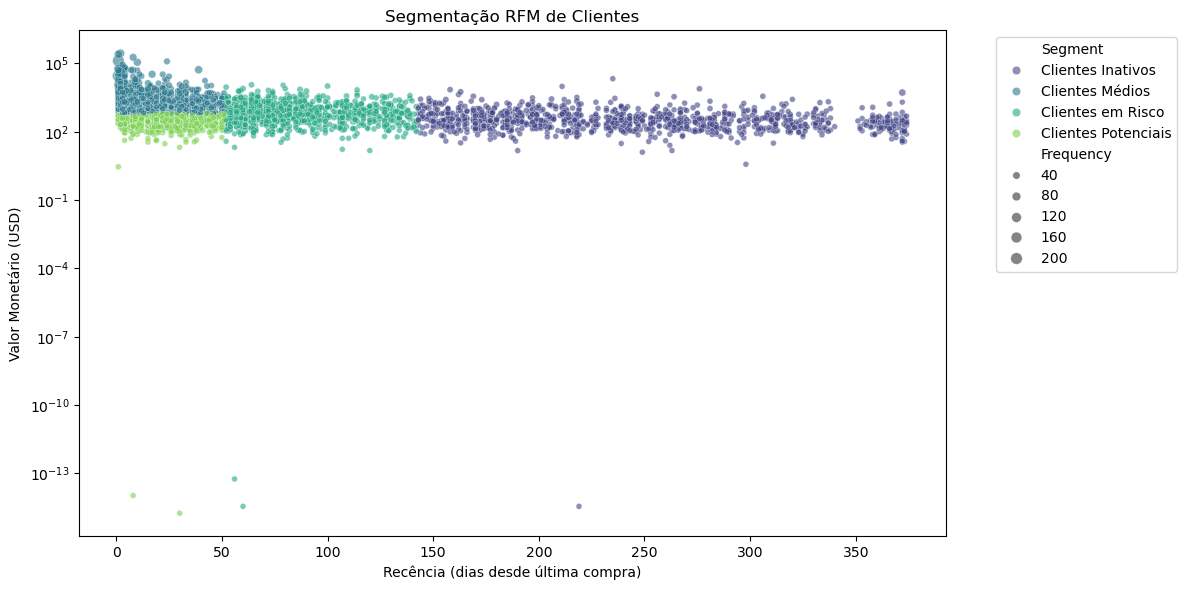

In [58]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Segment', 
                palette='viridis', alpha=0.6, size='Frequency')
plt.title('Segmentação RFM de Clientes')
plt.xlabel('Recência (dias desde última compra)')
plt.ylabel('Valor Monetário (USD)')
plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Essa segmentação RFM fornece insumos para ações de marketing direcionadas: por exemplo, Programa VIP para "Medios" e "Potenciais" aliados a campanhas de upsell/cross-sell. Promoções de reativação para “Em Risco”.

### 4.2 Clusterização K-Means (Agrupamento Automático)

Complementarmente, vamos aplicar o algoritmo de clusterização K-Means nos dados RFM para verificar se grupos semelhantes emergem de forma não supervisionada.   
Vamos padronizar as variáveis R, F, M (usando StandardScaler) e testar uma segmentação em 4 clusters.

In [59]:
# Preparando dados RFM para clustering (normalização)
rfm_values = rfm[['Recency','Frequency','Monetary']].fillna(0).values
rfm_values_scaled = StandardScaler().fit_transform(rfm_values)

# Aplicando K-Means com 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_values_scaled)

# Examinando características médias de cada cluster
print(rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean())


            Recency  Frequency       Monetary
Cluster                                      
0         42.400000   4.133228    1503.336308
1        247.385330   1.552461     477.182034
2          7.666667  76.166667  182108.075000
3         10.135417  34.854167   20123.066979


A saída acima (centroides médios de cada cluster) mostrou diferenciações coerentes com a análise RFM manual:  
- Cluster 0: Clientes com Recência baixa (compraram muito recentemente) porém Frequência baixa – essencialmente novos clientes (one-time recentes).  
- Cluster 1: Clientes de alta Recência (muito tempo sem comprar), baixa Frequência e baixo gasto – correspondem aos clientes inativos/perdidos.  
- Cluster 2: Clientes com baixa Recência (recentes), alta Frequência e alto Monetário – correspondendo aos “melhores clientes” identificados (um cluster de VIPs).  
- Cluster 3: Clientes com Recência média, Frequência e Monetário médios – um grupo de clientes regulares, sem extremos.

Com os segmentos identificados, é possível personalizar estratégias de marketing:  
- Para "melhores clientes" (cluster 2): manter a satisfação alta, oferecer vantagens exclusivas (frete grátis, acesso antecipado a lançamentos, brindes), pois são clientes de altíssimo valor.  
- Para Regulares (cluster 3): programas de fidelidade para aumentar gradativamente o engajamento, talvez estimulando indicações ou maior frequência de compra.  
- Para Novos (cluster 0): nutrir relacionamento, enviar conteúdo de produto, pedir feedback da primeira compra e oferecer um cupom de desconto para a próxima compra, visando aumentar a frequência.  
- Para Inativos (cluster 1): campanhas de reativação, possivelmente via email marketing personalizado (“Sentimos sua falta, aqui um desconto especial se voltar!”) ou ofertas em produtos relacionados ao histórico deles. Se não responderem, removê-los gradualmente de campanhas pode ser eficiente em custo.

## 5. Insights Estratégicos e Recomendações

Com base na análise exploratória e segmentação, a seguir são apresentadas as principais insights acionáveis e recomendações de estratégias para a loja online:

#### Redução de Cancelamentos/Devoluções: 
A taxa de cancelamento identificada é alta, impactando margem e satisfação. *Recomenda-se investigar a fundo os produtos com maiores devoluções (como evidenciado, alguns itens foram completamente devolvidos).*    
Melhoria no controle de qualidade é primordial – assegurar que produtos (especialmente os novos) sejam testados antes de vender em larga escala pode evitar devoluções em massa.   
Além disso, fornecer descrições e imagens mais acuradas no site pode alinhar expectativas e reduzir devoluções de produtos caros. Para itens frágeis ou de alto valor, melhorar a embalagem e logística diminui danos no transporte.   
Políticas de troca mais ágeis e suporte pró-ativo após a compra também podem converter potenciais devoluções em soluções (por exemplo, oferecer reparo ou desconto ao invés do retorno completo).

#### Aumento do Ticket Médio: 
Os dados mostram várias oportunidades para elevar o valor médio por pedido.   
Uma estratégia é implementar cross-sell e up-sell no e-commerce: por exemplo, ao adicionar um “Jumbo Bag Red Retrospot” ao carrinho, sugerir o “Jumbo Bag Pink Polkadot” (que frequentemente é comprada junto) com um pequeno desconto no combo. Da mesma forma, oferecer kits (bundles) de produtos complementares, como o conjunto de xícaras “Green Regency” + “Roses Regency” juntos por um preço especial, pode incentivar clientes a levar ambos.  
Outra tática é estabelecer um frete grátis acima de um valor mínimo de compra, encorajando os clientes a incluírem mais itens no carrinho para atingir o patamar.   
Programas de desconto progressivo (ex: 5% off na compra acima de £50, 10% acima de £100) também podem elevar o gasto por pedido.   
Por fim, aproveitar a base de clientes de alto valor identificados para vendas de produtos premium: comunicar lançamentos de itens exclusivos ou versões upscale de produtos populares pode elevar o ticket nessas vendas


#### Fidelização e Retenção de Clientes: 
Dado que muitos clientes compraram apenas uma vez, é crucial melhorar a retenção.   
Implementar um programa de fidelidade pode ser eficaz – por exemplo, acumular pontos a cada compra que podem ser trocados por descontos ou brindes, estimulando a recorrência.   
Para os “melhores clientes” e clientes frequentes, recompensas VIP (como cupons personalizados, atendimento prioritário, brindes surpresa em datas especiais) os farão se sentir valorizados e menos propensos a migrar para concorrentes.   
Já para os clientes em risco/inativos, montar campanhas de reativação: enviar e-mails relembrando produtos vistos ou relacionados às últimas compras deles, oferecer um cupom de retorno (“Volte e ganhe 15% off”) e destacar novidades pode reacender o interesse.   
Também é importante analisar feedbacks ou pesquisas de satisfação para entender porque não voltaram – por exemplo, se houve reclamação de atendimento ou qualidade, atuar diretamente nessas frentes.   
A personalização de comunicação de acordo com os segmentos (RFM/cluster) aumenta a relevância: clientes fiéis recebem novidades e ofertas exclusivas; clientes novos recebem tutorial de uso do produto comprado ou reviews para ganhar confiança; clientes sumidos recebem saudação e incentivo para voltar.

#### Otimização de Promoções e Marketing: 
Os insights de sazonalidade indicam que campanhas promocionais devem ser calibradas com o calendário anual – por exemplo, intensificar marketing antes do pico de novembro (Black Friday/Cyber Monday e Natal) para capitalizar o interesse, e planejar promoções de liquidação em períodos mais fracos (início do ano) para estimular demanda.  
Os produtos mais vendidos identificados podem ser usados como carro-chefe em campanhas (p.ex., destacar os mais populares na página inicial, ou usar o “Jumbo Bag” em anúncios para atrair tráfego, pois é um item de apelo amplo).   
Por outro lado, a empresa pode precisar renovar o catálogo ou melhorar produtos que tiveram desempenho fraco ou alto cancelamento, para não desperdiçar esforços de marketing neles.   
Com a segmentação de clientes, é possível fazer campanhas segmentadas: por exemplo, campanhas de email separadas – uma com produtos premium e novidades para clientes de alto valor, e outra oferecendo descontos mais agressivos em produtos de baixo custo para clientes sensíveis a preço que compraram pouco. Assim, o marketing torna-se mais eficiente, falando a língua de cada grupo de clientes.

### Conclusão

A análise de dados revelou padrões valiosos que orientam decisões: 
- a empresa deve focar em manter e replicar o sucesso com itens populares, 
- corrigir ou eliminar pontos de atrito (produtos problemáticos e alto índice de devolução), e 
- personalizar o relacionamento com o cliente conforme seu perfil. 

Implementando essas recomendações – controle de qualidade, cross-sell estratégico, programas de fidelidade, campanhas segmentadas e melhoria contínua da experiência de compra – a loja online estará bem posicionada para aumentar suas vendas e margens e construir uma base de clientes mais leais e satisfeitos.

## Fim